In [ ]:
# --- repo root + config (walk parents; do not use ../..) ---
from pathlib import Path
import json
import yaml

def _repo_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / "config" / "config.yaml").is_file():
            return p
    raise FileNotFoundError("config/config.yaml not found walking from " + str(start))

PROJECT_ROOT = _repo_root()
CFG_YAML = yaml.safe_load((PROJECT_ROOT / "config" / "config.yaml").read_text(encoding="utf-8"))
_cfg_json = PROJECT_ROOT / "config" / "config.json"
if _cfg_json.is_file():
    with open(_cfg_json, encoding="utf-8") as _f:
        CFG = json.load(_f)



# RQ4: Abstention utility of semantic entropy on MedMentions
## SIT723 — Masters Research Techniques and Applications

**Dataset:** MedMentions ST21pv (biomedical literature mentions).

**Input:** `outputs/rq1/entropy_full_umls.csv`
(`normalised_semantic_entropy_full`, `mean_accuracy_full`).
Mapping confidence is used if present as `mapping_confidence`; otherwise this run is
**entropy vs random only**.

**Mirrors** the CADEC RQ4 three-way protocol (coverage 1.0→0.1, selective accuracy,
risk, AURC).

**Outputs:**
- `outputs/rq1/rq4_risk_coverage_medmentions.csv`
- `outputs/rq1/figures/rq4_risk_coverage_medmentions.png`

## RQ4 statement (MedMentions)

**Research question (RQ4):** Can UMLS-grounded semantic entropy work as an abstention
signal that improves reliability of retained predictions on MedMentions?

**Protocol (same as CADEC RQ4):** per model, risk–coverage curves for entropy
(sort ascending), mapping confidence (sort descending, if available), and random.

In [1]:
# === RQ4 LOAD (MedMentions full-UMLS entropy) ================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = Path(".").resolve()

OUT_DIR = PROJECT_ROOT / "outputs" / "rq1"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATH_ENT = OUT_DIR / "entropy_full_umls.csv"
if not PATH_ENT.exists():
    raise FileNotFoundError(
        f"RQ4 MedMentions requires {PATH_ENT}. Run RQ1_PART2 first."
    )

df_raw = pd.read_csv(PATH_ENT)
required = [
    "instance_id", "model_name",
    "normalised_semantic_entropy_full", "mean_accuracy_full",
]
_missing = [c for c in required if c not in df_raw.columns]
if _missing:
    raise KeyError(f"{PATH_ENT} missing columns: {_missing}")

HAS_MAPPING_CONFIDENCE = "mapping_confidence" in df_raw.columns
print(f"Loaded MedMentions entropy: {PATH_ENT} | rows={len(df_raw):,}")
print(f"  models: {sorted(df_raw['model_name'].unique())}")
if HAS_MAPPING_CONFIDENCE:
    print("  mapping_confidence: AVAILABLE — three-way (entropy / confidence / random)")
else:
    print(
        "  mapping_confidence: UNAVAILABLE in entropy_full_umls.csv —\n"
        "  running entropy vs random only for now "
        "(no mapping_confidence column to join)."
    )

df = df_raw.rename(columns={
    "normalised_semantic_entropy_full": "normalised_entropy",
    "mean_accuracy_full": "accuracy",
}).copy()

drop_cols = ["normalised_entropy"]
if HAS_MAPPING_CONFIDENCE:
    drop_cols.append("mapping_confidence")
n_before = len(df)
df = df.dropna(subset=drop_cols).copy()
df["accuracy"] = df["accuracy"].astype(float)
if HAS_MAPPING_CONFIDENCE:
    df["mapping_confidence"] = df["mapping_confidence"].astype(float)

MODELS = sorted(df["model_name"].unique())
print(f"Dropped NaN on {drop_cols}: {n_before - len(df):,} | analysis rows={len(df):,}")
_agg = {
    "n": ("instance_id", "size"),
    "mean_H": ("normalised_entropy", "mean"),
    "mean_acc": ("accuracy", "mean"),
}
if HAS_MAPPING_CONFIDENCE:
    _agg["mean_conf"] = ("mapping_confidence", "mean")
    _agg["std_conf"] = ("mapping_confidence", "std")
print(df.groupby("model_name").agg(**{k: v for k, v in [
    ("n", ("instance_id", "size")),
    ("mean_H", ("normalised_entropy", "mean")),
    ("mean_acc", ("accuracy", "mean")),
] + ([("mean_conf", ("mapping_confidence", "mean")),
        ("std_conf", ("mapping_confidence", "std"))] if HAS_MAPPING_CONFIDENCE else [])
}).loc[MODELS].round(4))

Loaded MedMentions entropy: /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/entropy_full_umls.csv | rows=1,650
  models: ['BERT-base', 'BioBERT', 'PubMedBERT']
  mapping_confidence: AVAILABLE — three-way (entropy / confidence / random)
Dropped NaN on ['normalised_entropy', 'mapping_confidence']: 13 | analysis rows=1,637
              n  mean_H  mean_acc  mean_conf  std_conf
model_name                                            
BERT-base   538  0.1239    0.4471     0.8492    0.1698
BioBERT     549  0.1272    0.4526     0.8462    0.1697
PubMedBERT  550  0.1304    0.4555     0.8460    0.1696


## Selective prediction: risk–coverage sweep (mirror CADEC RQ4)

Per model on MedMentions:
1. **Entropy** — sort by `normalised_entropy` ascending.
2. **Mapping confidence** — sort descending (**if available**).
3. **Random** — shuffle ranking, averaged over several seeds.

Coverage 1.0 → 0.1; selective accuracy = mean(accuracy) on retained;
risk = 1 − selective accuracy; AURC per signal.

In [2]:
# === RQ4 RISK–COVERAGE SWEEP (MedMentions) ====================================
COVERAGE_GRID = np.round(np.arange(1.00, 0.09, -0.05), 2)  # 1.00 … 0.10
LOW_COVERAGES = [c for c in COVERAGE_GRID if 0.1 - 1e-9 <= c <= 0.5 + 1e-9]
N_RANDOM = 20
RNG = np.random.default_rng(42)

print("Coverage grid:", COVERAGE_GRID.tolist())
print("Low-coverage diagnostic levels (0.1–0.5):", LOW_COVERAGES)


def selective_curve(y: np.ndarray, score: np.ndarray, coverages=COVERAGE_GRID,
                    higher_is_better: bool = False):
    """Retain top `coverage` fraction by score; low score kept first unless higher_is_better."""
    n = len(y)
    order = np.argsort(score)
    if higher_is_better:
        order = order[::-1]
    ranked_y = y[order]
    rows = []
    for cov in coverages:
        k = max(1, int(np.ceil(float(cov) * n)))
        acc = float(np.mean(ranked_y[:k]))
        rows.append({
            "coverage": float(cov),
            "n_keep": int(k),
            "n_total": int(n),
            "selective_accuracy": acc,
            "risk": 1.0 - acc,
        })
    return rows


def aurc_from_curve(coverages, risks):
    c = np.asarray(coverages, dtype=float)
    r = np.asarray(risks, dtype=float)
    order = np.argsort(c)
    trapz = getattr(np, "trapezoid", None) or np.trapz
    return float(trapz(r[order], c[order]))


curve_rows = []
aurc_rows = []

for model in MODELS:
    g = df[df["model_name"] == model].reset_index(drop=True)
    y = g["accuracy"].to_numpy(dtype=float)
    h = g["normalised_entropy"].to_numpy(dtype=float)
    n = len(y)

    # (1) Entropy — low H first
    ent_curve = selective_curve(y, h, higher_is_better=False)
    for r in ent_curve:
        r.update({"model": model, "signal": "entropy"})
        curve_rows.append(r)
    aurc_ent = aurc_from_curve(
        [r["coverage"] for r in ent_curve],
        [r["risk"] for r in ent_curve],
    )

    # (2) Mapping confidence — high first (if available)
    aurc_conf = np.nan
    conf_std = np.nan
    if HAS_MAPPING_CONFIDENCE:
        conf = g["mapping_confidence"].to_numpy(dtype=float)
        conf_std = float(np.std(conf, ddof=1)) if n > 1 else 0.0
        conf_curve = selective_curve(y, conf, higher_is_better=True)
        for r in conf_curve:
            r.update({"model": model, "signal": "mapping_confidence"})
            curve_rows.append(r)
        aurc_conf = aurc_from_curve(
            [r["coverage"] for r in conf_curve],
            [r["risk"] for r in conf_curve],
        )

    # (3) Random
    acc_by_cov = {float(c): [] for c in COVERAGE_GRID}
    for _ in range(N_RANDOM):
        perm = RNG.permutation(n)
        ranked_y = y[perm]
        for cov in COVERAGE_GRID:
            k = max(1, int(np.ceil(float(cov) * n)))
            acc_by_cov[float(cov)].append(float(np.mean(ranked_y[:k])))

    rand_curve = []
    for cov in COVERAGE_GRID:
        accs = np.asarray(acc_by_cov[float(cov)])
        acc = float(accs.mean())
        row = {
            "model": model,
            "signal": "random",
            "coverage": float(cov),
            "n_keep": max(1, int(np.ceil(float(cov) * n))),
            "n_total": int(n),
            "selective_accuracy": acc,
            "risk": 1.0 - acc,
        }
        curve_rows.append(row)
        rand_curve.append(row)

    aurc_rand = aurc_from_curve(
        [r["coverage"] for r in rand_curve],
        [r["risk"] for r in rand_curve],
    )
    aurc_rows.append({
        "model": model,
        "n": n,
        "AURC_entropy": aurc_ent,
        "AURC_confidence": aurc_conf,
        "AURC_random": aurc_rand,
        "mapping_confidence_std": conf_std,
    })

df_curves = pd.DataFrame(curve_rows)
df_aurc = pd.DataFrame(aurc_rows)

df_out = (
    df_curves[["model", "signal", "coverage", "selective_accuracy", "risk"]]
    .sort_values(["model", "signal", "coverage"], ascending=[True, True, False])
    .reset_index(drop=True)
)
out_csv = OUT_DIR / "rq4_risk_coverage_medmentions.csv"
df_out.to_csv(out_csv, index=False)
print(f"Saved {out_csv} | rows={len(df_out):,} | signals={sorted(df_out['signal'].unique())}")

print("\n=== AURC (lower is better) ===")
_aurc_cols = ["AURC_entropy", "AURC_confidence", "AURC_random", "mapping_confidence_std"]
display(df_aurc.set_index("model").loc[MODELS][_aurc_cols].round(4))

Coverage grid: [1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]
Low-coverage diagnostic levels (0.1–0.5): [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]
Saved /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/rq4_risk_coverage_medmentions.csv | rows=171 | signals=['entropy', 'mapping_confidence', 'random']

=== AURC (lower is better) ===


,AURC_entropy,AURC_confidence,AURC_random,mapping_confidence_std
model,,,,
BERT-base,0.4089,0.3675,0.4947,0.1698
BioBERT,0.3753,0.3625,0.4936,0.1697
PubMedBERT,0.3822,0.3641,0.4932,0.1696


## Risk–coverage curves (MedMentions)

Risk \((1 - \text{selective accuracy})\) vs coverage. Lower is better.

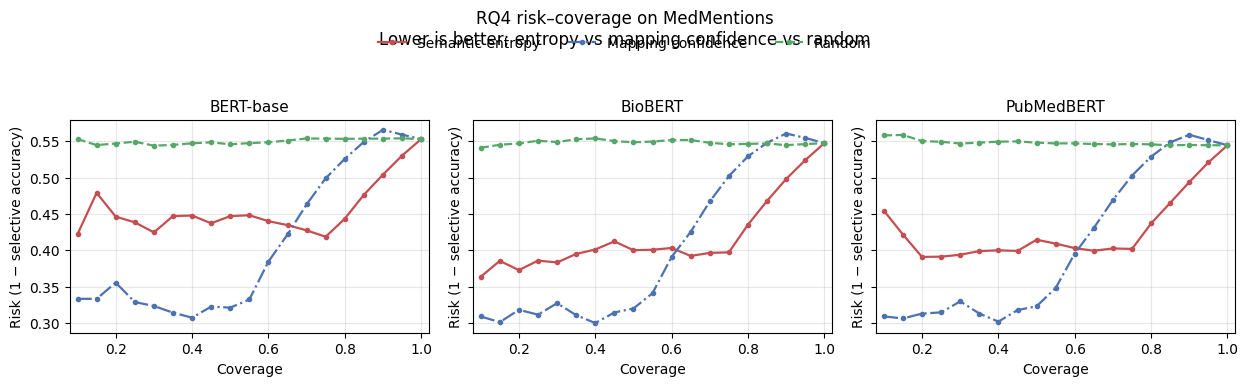

Saved /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/figures/rq4_risk_coverage_medmentions.png


In [3]:
# === RQ4 RISK–COVERAGE PLOT (MedMentions) ====================================
n_models = len(MODELS)
ncols = min(3, n_models)
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows),
                         sharex=False, sharey=True)
axes = np.atleast_1d(axes).ravel()

# Prefer on-disk curves (include signal=="combined"); plotting-only — no recompute
_curve_csv = OUT_DIR / "rq4_risk_coverage_medmentions.csv"
if _curve_csv.is_file() and "combined" in set(pd.read_csv(_curve_csv, usecols=["signal"])["signal"]):
    df_curves = pd.read_csv(_curve_csv)
    print(f"Plotting from {_curve_csv} | signals={sorted(df_curves['signal'].unique())}")

_plot_specs = [
    ("entropy", "-", "#C44E52", "Semantic entropy"),
    ("mapping_confidence", "-.", "#4C72B0", "Mapping confidence"),
    ("random", "--", "#55A868", "Random"),
    ("combined", "--", "#7a52a8", "combined"),
]

for ax, model in zip(axes, MODELS):
    sub = df_curves[df_curves["model"] == model]
    for signal, style, color, label in _plot_specs:
        s = sub[sub["signal"] == signal].sort_values("coverage")
        if s.empty:
            continue
        ax.plot(
            s["coverage"], s["risk"],
            linestyle=style, marker="o", ms=3, lw=1.6,
            color=color, label=label,
        )
    ax.set_title(model, fontsize=11)
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Risk")
    ax.set_xlim(0.08, 1.02)
    ax.grid(True, alpha=0.3)

for ax in axes[n_models:]:
    ax.axis("off")

for _ax in axes[:n_models]:
    _ax.set_xlabel("Coverage")
    _ax.set_ylabel("Risk")
    _ax.tick_params(labelbottom=True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(4, len(handles)),
           frameon=False, bbox_to_anchor=(0.5, 1.02))
_subtitle = (
    "entropy / confidence / random / combined"
    if HAS_MAPPING_CONFIDENCE else
    "entropy vs random (mapping confidence unavailable)"
)
fig.suptitle(
    f"RQ4 risk-coverage on MedMentions
risk = 1 − selective accuracy; lower is better",
    y=1.06, fontsize=12,
)
plt.tight_layout()
_fig = FIG_DIR / "rq4_risk_coverage_medmentions.png"
fig.savefig(_fig, dpi=150, bbox_inches="tight")
_fig_all = PROJECT_ROOT / "outputs" / "figures" / "all_rq_figures" / "RQ4_risk_coverage_medmentions.png"
_fig_all.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_all, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {_fig}")
print(f"Saved {_fig_all}")


## AURC table + low-coverage diagnostic (entropy vs confidence)

Same CADEC diagnostic: at each coverage in \([0.1, 0.5]\), count how many levels
entropy has **lower risk** than mapping confidence (entropy beats confidence).

In [4]:
# === RQ4 SUMMARY + LOW-COVERAGE DIAGNOSTIC ===================================
print("=== MedMentions: AURC table ===")
display(df_aurc.set_index("model").loc[MODELS][
    ["AURC_entropy", "AURC_confidence", "AURC_random", "mapping_confidence_std"]
].round(4))

if not HAS_MAPPING_CONFIDENCE:
    print(
        "\nNOTE: mapping_confidence is unavailable in outputs/rq1/entropy_full_umls.csv.\n"
        "This run is entropy vs random only. Low-coverage entropy-vs-confidence "
        "diagnostic is skipped until mapping_confidence is added to the MedMentions "
        "entropy table (as done for CADEC)."
    )
else:
    print("\n=== Low-coverage (0.1–0.5): levels where entropy beats confidence ===")
    print("(entropy beats confidence iff risk_entropy < risk_confidence at that coverage)")
    diag_rows = []
    for model in MODELS:
        sub = df_curves[df_curves["model"] == model]
        n_beat = 0
        beat_levels = []
        for cov in LOW_COVERAGES:
            r_e = sub[(sub["signal"] == "entropy") & np.isclose(sub["coverage"], cov)]
            r_c = sub[(sub["signal"] == "mapping_confidence") & np.isclose(sub["coverage"], cov)]
            if r_e.empty or r_c.empty:
                continue
            risk_e = float(r_e["risk"].iloc[0])
            risk_c = float(r_c["risk"].iloc[0])
            if risk_e < risk_c:
                n_beat += 1
                beat_levels.append(float(cov))
        diag_rows.append({
            "model": model,
            "n_low_levels": len(LOW_COVERAGES),
            "n_entropy_beats_confidence": n_beat,
            "levels_entropy_wins": beat_levels,
        })
        print(
            f"{model}: entropy beats confidence at {n_beat}/{len(LOW_COVERAGES)} "
            f"low-coverage levels {beat_levels}"
        )
    display(pd.DataFrame(diag_rows).set_index("model"))

# Per-model printed AURC lines (mirror CADEC summary style)
print("\n=== Per-model AURC ===")
for model in MODELS:
    ar = df_aurc.loc[df_aurc["model"] == model].iloc[0]
    conf_str = (
        f"AURC_confidence={ar['AURC_confidence']:.4f}"
        if pd.notna(ar["AURC_confidence"]) else
        "AURC_confidence=NA (unavailable)"
    )
    print(
        f"{model}: AURC_entropy={ar['AURC_entropy']:.4f} | {conf_str} | "
        f"AURC_random={ar['AURC_random']:.4f}"
    )

# Assert entropy abstention helps @ 50% vs 100% (same CADEC check)
print("\n=== Assert: entropy selective acc @50% > @100% ===")
for model in MODELS:
    ent = df_curves[(df_curves["model"] == model) & (df_curves["signal"] == "entropy")]
    acc100 = float(ent.loc[np.isclose(ent["coverage"], 1.0), "selective_accuracy"].iloc[0])
    acc50 = float(ent.loc[np.isclose(ent["coverage"], 0.5), "selective_accuracy"].iloc[0])
    assert acc50 > acc100, (
        f"ASSERT FAIL [{model}]: acc@50% ({acc50:.4f}) did not exceed acc@100% ({acc100:.4f})."
    )
    print(f"ASSERT OK [{model}]: acc@50% ({acc50:.4f}) > acc@100% ({acc100:.4f})")

print(
    f"\nArtifacts:\n  {OUT_DIR / 'rq4_risk_coverage_medmentions.csv'}\n"
    f"  {FIG_DIR / 'rq4_risk_coverage_medmentions.png'}"
)

=== MedMentions: AURC table ===


,AURC_entropy,AURC_confidence,AURC_random,mapping_confidence_std
model,,,,
BERT-base,0.4089,0.3675,0.4947,0.1698
BioBERT,0.3753,0.3625,0.4936,0.1697
PubMedBERT,0.3822,0.3641,0.4932,0.1696



=== Low-coverage (0.1–0.5): levels where entropy beats confidence ===
(entropy beats confidence iff risk_entropy < risk_confidence at that coverage)
BERT-base: entropy beats confidence at 0/9 low-coverage levels []
BioBERT: entropy beats confidence at 0/9 low-coverage levels []
PubMedBERT: entropy beats confidence at 0/9 low-coverage levels []


,n_low_levels,n_entropy_beats_confidence,levels_entropy_wins
model,,,
BERT-base,9,0,[]
BioBERT,9,0,[]
PubMedBERT,9,0,[]



=== Per-model AURC ===
BERT-base: AURC_entropy=0.4089 | AURC_confidence=0.3675 | AURC_random=0.4947
BioBERT: AURC_entropy=0.3753 | AURC_confidence=0.3625 | AURC_random=0.4936
PubMedBERT: AURC_entropy=0.3822 | AURC_confidence=0.3641 | AURC_random=0.4932

=== Assert: entropy selective acc @50% > @100% ===
ASSERT OK [BERT-base]: acc@50% (0.5530) > acc@100% (0.4471)
ASSERT OK [BioBERT]: acc@50% (0.5998) > acc@100% (0.4526)
ASSERT OK [PubMedBERT]: acc@50% (0.5855) > acc@100% (0.4555)

Artifacts:
  /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/rq4_risk_coverage_medmentions.csv
  /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/figures/rq4_risk_coverage_medmentions.png
